<a href="https://colab.research.google.com/github/LAXMI15PRIYA/sentiment-analysis-wordcloud/blob/main/Sentiment_Analysis_%26_Word_Cloud_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from textblob import TextBlob
from wordcloud import WordCloud


df=pd.read_csv("Sentiment_Analysis .csv")
df.head(10)

,Sentences
0,The product's exceptional quality and performa...
1,Poor customer support and the product's subpar...
2,The service met standard requirements without ...
3,Outstanding customer service accompanied the p...
4,The product's failure to meet basic requiremen...
5,The service provided met basic needs without n...
6,Remarkable product quality and performance exc...
7,Poor customer service and a faulty product led...
8,"The service provided was average, meeting mini..."
9,"The purchase proved delightful, with the produ..."


In [ ]:
#Define the sentiment analysis
def get_sentiment(text):
  meaning=TextBlob(text)

  if meaning.sentiment.polarity>0:
    return"Positive"

  elif meaning.sentiment.polarity<0:
    return "Negative"
  else:
     return "Neutral"

In [ ]:
#Apply the sentiment analysis to each sentences
df["Sentiment"]=df["Sentences"].apply(get_sentiment)
df.head(20)

,Sentences,Sentiment
0,The product's exceptional quality and performa...,Positive
1,Poor customer support and the product's subpar...,Negative
2,The service met standard requirements without ...,Positive
3,Outstanding customer service accompanied the p...,Positive
4,The product's failure to meet basic requiremen...,Negative
5,The service provided met basic needs without n...,Positive
6,Remarkable product quality and performance exc...,Positive
7,Poor customer service and a faulty product led...,Negative
8,"The service provided was average, meeting mini...",Negative
9,"The purchase proved delightful, with the produ...",Positive


In [ ]:
df.to_excel("Sentiment_Labeled.xlsx",index=False)

In [ ]:
sam=df["Sentiment"].value_counts()
print(sam)

Sentiment
Positive    12
Negative     9
Neutral      1
Name: count, dtype: int64


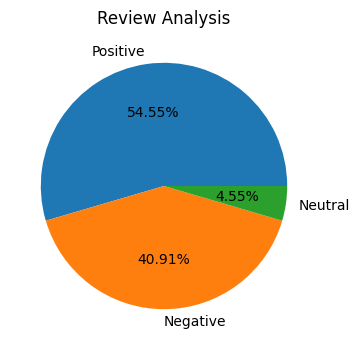

In [ ]:
plt.figure(figsize=(6,4))
plt.pie(sam,labels=sam.index,autopct="%1.2f%%")
plt.title("Review Analysis")
plt.show()

In [ ]:
#Filter out all the negative Sentences
negative_reviews=df[df["Sentiment"]=="Negative"]
negative_reviews.head(20)

,Sentences,Sentiment
1,Poor customer support and the product's subpar...,Negative
4,The product's failure to meet basic requiremen...,Negative
7,Poor customer service and a faulty product led...,Negative
8,"The service provided was average, meeting mini...",Negative
13,Dreadful customer support coupled with a defec...,Negative
16,Severe product shortcomings led to considerabl...,Negative
17,"The service was standard, meeting basic needs ...",Negative
19,Disappointing product quality and poor custome...,Negative
20,"The service provided was average, meeting basi...",Negative


In [ ]:
#Combine all negative sentences into one single string
all_negative_text=" ".join(negative_reviews["Sentences"])


In [ ]:
print(all_negative_text)

Poor customer support and the product's subpar performance led to frustration and disappointment, regretting the purchase entirely. The product's failure to meet basic requirements resulted in immense inconvenience and frustration, causing regret over the purchase. Poor customer service and a faulty product led to significant inconvenience and frustration, resulting in regret over the purchase decision. The service provided was average, meeting minimum requirements without standout features, resulting in a standard user experience. Dreadful customer support coupled with a defective product caused immense frustration and disappointment, regretting the purchase. Severe product shortcomings led to considerable dissatisfaction and regret over the purchase due to a lack of promised functionality. The service was standard, meeting basic needs without noteworthy features, resulting in an average user experience without extremes. Disappointing product quality and poor customer service resulted

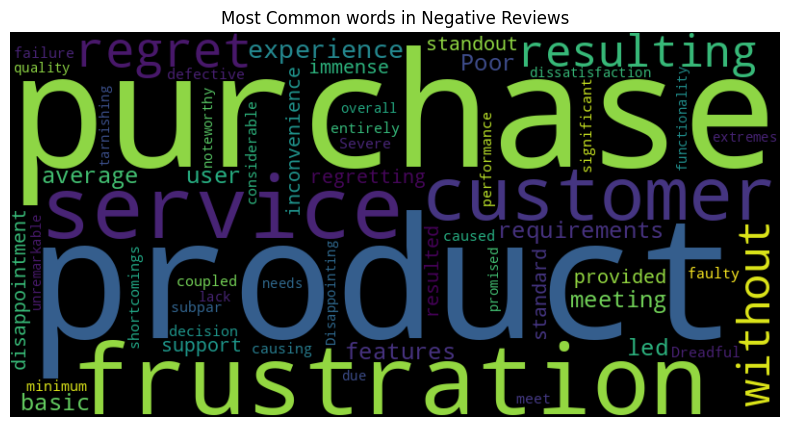

In [25]:
#Create a Word Cloud for the negative reviews
neel=WordCloud(width=800,height=400,background_color="black").generate(all_negative_text)

#Plot theWord Cloud
plt.figure(figsize=(10,5))
plt.imshow(neel,interpolation="bilinear")
plt.title("Most Common words in Negative Reviews")
plt.axis("off")
plt.show()